In [1]:
import numpy as np
import tensorflow as tf

2026-07-20 16:21:17.994535: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-20 16:21:17.994959: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-20 16:21:17.997369: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-20 16:21:18.003888: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-20 16:21:18.015434: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Load the data

In [2]:
npz = np.load('./Data/Audiobooks_data_train.npz')
train_inputs = npz['inputs'].astype(float)
train_targets = npz['outputs'].astype(int)

npz = np.load('./Data/Audiobooks_data_validation.npz')
validation_inputs = npz['inputs'].astype(float)
validation_targets = npz['outputs'].astype(int)

npz = np.load('./Data/Audiobooks_data_test.npz')
test_inputs = npz['inputs'].astype(float)
test_targets = npz['outputs'].astype(int)

train_inputs.shape


(3131, 6)

Model

In [3]:
input_size = train_inputs.shape[1]
output_size = 2
hidden_layer_size = 150

model = tf.keras.Sequential([
#        tf.keras.layers.Flatten(input_size=(X,Y,1)),
        tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
        tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
        tf.keras.layers.Dense(output_size, activation='softmax')
])
#model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

batch_size = 100
epochs = 150
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_inputs,
         train_targets,
         batch_size = batch_size,
         epochs = epochs,
         callbacks=[early_stopping],
         validation_data=(validation_inputs, validation_targets),
         verbose=2)


Epoch 1/150
32/32 - 1s - 24ms/step - accuracy: 0.7439 - loss: 0.5128 - val_accuracy: 0.7857 - val_loss: 0.4364
Epoch 2/150
32/32 - 0s - 3ms/step - accuracy: 0.7796 - loss: 0.4089 - val_accuracy: 0.7961 - val_loss: 0.4039
Epoch 3/150
32/32 - 0s - 3ms/step - accuracy: 0.7860 - loss: 0.3885 - val_accuracy: 0.7991 - val_loss: 0.3959
Epoch 4/150
32/32 - 0s - 2ms/step - accuracy: 0.7902 - loss: 0.3829 - val_accuracy: 0.7961 - val_loss: 0.3903
Epoch 5/150
32/32 - 0s - 2ms/step - accuracy: 0.7914 - loss: 0.3782 - val_accuracy: 0.7649 - val_loss: 0.3977
Epoch 6/150
32/32 - 0s - 2ms/step - accuracy: 0.7927 - loss: 0.3798 - val_accuracy: 0.8080 - val_loss: 0.3898
Epoch 7/150
32/32 - 0s - 2ms/step - accuracy: 0.7790 - loss: 0.3911 - val_accuracy: 0.7440 - val_loss: 0.4026
Epoch 8/150
32/32 - 0s - 2ms/step - accuracy: 0.7924 - loss: 0.3747 - val_accuracy: 0.8095 - val_loss: 0.3785
Epoch 9/150
32/32 - 0s - 3ms/step - accuracy: 0.8020 - loss: 0.3719 - val_accuracy: 0.8006 - val_loss: 0.3816
Epoch 10/

In [4]:
test_loss, test_accuracy = model.evaluate(test_inputs, test_targets)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8003 - loss: 0.3862 


In [5]:
import joblib
joblib.dump(model, "./Data/model.pkl")

['./Data/model.pkl']

In [6]:
# from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# y_pred_train = (model.predict(train_inputs)[:,1] > 0.6).astype(int)
# y_pred_val = (model.predict(validation_inputs)[:,1] > 0.6).astype(int)
# y_pred_test = (model.predict(test_inputs) > 0.6)[:,1].astype(int)

# # y_pred_train = np.argmax(model.predict(train_inputs), axis=1)
# # y_pred_val = np.argmax(model.predict(validation_inputs), axis=1)
# # y_pred_test = np.argmax(model.predict(test_inputs), axis=1)


# # y_prob_train = model.predict(train_inputs)[:,1]
# # y_pred_train = np.argmax(model.predict(train_inputs), axis=1)
# # y_prob_val = model.predict(validation_inputs)[:,1]
# # y_pred_val = np.argmax(model.predict(validation_inputs), axis=1)
# # y_prob_test = model.predict(test_inputs)[:,1]
# # y_pred_test = np.argmax(model.predict(test_inputs), axis=1)


# #accuracy = model.score(test_inputs, test_targets)
# cm = confusion_matrix(test_targets, y_pred_test)
# accuracy = accuracy_score(test_targets, y_pred_test)
# precision = precision_score(test_targets, y_pred_test)
# recall = recall_score(test_targets, y_pred_test)
# f1 = f1_score(test_targets, y_pred_test)

# print("Confusion Matrix:\n", cm)
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1 Score:", f1)

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Neural Network probabilities for class 1 = purchase
# NN has Dense(2, activation='softmax'), so column 1 is P(purchase=1)
y_prob_train = model.predict(train_inputs)[:, 1]
y_prob_val = model.predict(validation_inputs)[:, 1]
y_prob_test = model.predict(test_inputs)[:, 1]

# Classification labels using chosen threshold
threshold = 0.7
y_pred_train = (y_prob_train >= threshold).astype(int)
y_pred_val = (y_prob_val >= threshold).astype(int)
y_pred_test = (y_prob_test >= threshold).astype(int)

# Final model evaluation should be reported on the test set only
cm = confusion_matrix(test_targets, y_pred_test)
accuracy = accuracy_score(test_targets, y_pred_test)
precision = precision_score(test_targets, y_pred_test)
recall = recall_score(test_targets, y_pred_test)
f1 = f1_score(test_targets, y_pred_test)

print("Confusion Matrix:", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step
Confusion Matrix: [[329  30]
 [110 202]]
Accuracy: 0.7913561847988078
Precision: 0.8706896551724138
Recall: 0.6474358974358975
F1 Score: 0.7426470588235294


In [8]:
np.savez('./Data/Audiobooks_data_train_pred', inputs=train_inputs, outputs=y_pred_train)
np.savez('./Data/Audiobooks_data_validation_pred', inputs=validation_inputs, outputs=y_pred_val)
np.savez('./Data/Audiobooks_data_test_pred', inputs=test_inputs, outputs=y_pred_test)

In [9]:
import pandas as pd

df = pd.DataFrame({
    'y_true': test_targets,
    'y_score': y_prob_test
})

df = df.sort_values(by='y_score', ascending=False).reset_index(drop=True)

In [10]:
baseline = df['y_true'].mean() #out of all the users how many actually bought

def precision_at_k(df, k):
    cutoff = int(len(df) * k)
    top_k = df.iloc[:cutoff]
    return top_k['y_true'].mean()

precision_topX = {}
lift = {}
for k in [0.1,0.2,0.3,0.4,0.5]:
    precision_topX[k] = precision_at_k(df, k)
    lift[k] = precision_topX[k]/baseline
    
    print(f"Baseline conversion rate: {baseline:0.2f} ({baseline*100:0.2f}%)")
    print(f"Precision@{k*100.0:0.0f}%: {precision_topX[k]:0.2f} ({precision_topX[k]*100:0.2f}%)")
    
    print(f"Lift@{k*100.0:0.0f}%: {lift[k]:.2f}x")    
    print(f"If baseline conversion = {baseline*100:0.2f}% then Precision@{k*100:0.0f}% = {precision_topX[k]*100:0.2f}%")
    print(f"If I target top {k*100}% users, {precision_topX[k]*100:0.2f}% may actually convert.")
    print(f"Those top {k*100}% users are {lift[k]:0.2f}x more likely to convert than a random test-set user.")


Baseline conversion rate: 0.46 (46.50%)
Precision@10%: 1.00 (100.00%)
Lift@10%: 2.15x
If baseline conversion = 46.50% then Precision@10% = 100.00%
If I target top 10.0% users, 100.00% may actually convert.
Those top 10.0% users are 2.15x more likely to convert than a random test-set user.
Baseline conversion rate: 0.46 (46.50%)
Precision@20%: 0.96 (95.52%)
Lift@20%: 2.05x
If baseline conversion = 46.50% then Precision@20% = 95.52%
If I target top 20.0% users, 95.52% may actually convert.
Those top 20.0% users are 2.05x more likely to convert than a random test-set user.
Baseline conversion rate: 0.46 (46.50%)
Precision@30%: 0.90 (89.55%)
Lift@30%: 1.93x
If baseline conversion = 46.50% then Precision@30% = 89.55%
If I target top 30.0% users, 89.55% may actually convert.
Those top 30.0% users are 1.93x more likely to convert than a random test-set user.
Baseline conversion rate: 0.46 (46.50%)
Precision@40%: 0.83 (82.84%)
Lift@40%: 1.78x
If baseline conversion = 46.50% then Precision@40% 

In [11]:
# # user-level export
# user_export = pd.DataFrame({
#     'model': 'Neural Network',
#     'y_true': test_targets,
#     'y_score': y_prob_test,
#     'y_pred': y_pred_test
# })
# user_export.to_csv('NN_user_predictions.csv', index=False)

# # metric export
# metrics_export = pd.DataFrame({
#     'model': ['Neural Network'],
#     'accuracy': [accuracy],
#     'recall': [recall],
#     'f1': [f1],
#     'baseline_conversion_at': [baseline*100.0],
#     'true_neg': [cm[0, 0]],
#     'false_pos': [cm[0, 1]],
#     'false_neg': [cm[1, 0]],
#     'true_pos': [cm[1, 1]]
# })

# for k in precision:
#     metrics_export[f'precision @{k*100}%']= precision[k]
#     metrics_export[f'lift @{k*100}%']= lift[k]


    

# metrics_export.to_csv('NN_model_metrics.csv', index=False)

In [12]:
# user-level export
user_export = pd.DataFrame({
    'model': 'Logistic Regression',
    'y_true': test_targets,
    'y_score': y_prob_test,
    'y_pred': y_pred_test
})
user_export.to_csv('./Data/logistic_user_predictions.csv', index=False)

# metric export
metrics_export = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1', 'baseline_conversion_at', 'true_neg', 'false_pos', 'false_neg', 'true_pos'],
    'NN':[accuracy, precision, recall, f1, baseline*100.0, cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]]

})

# add precision and lift as rows
for k in precision_topX:
    new_rows = pd.DataFrame({
        'metric': [
            f'precision_at_{int(k*100)}%',
            f'lift_at_{int(k*100)}%'
        ],
        'NN': [
            precision_topX[k],
            lift[k]
        ]
    })

    metrics_export = pd.concat([metrics_export, new_rows], ignore_index=True)
metrics_export.to_csv('./Data/NN_model_metrics.csv', index=False)

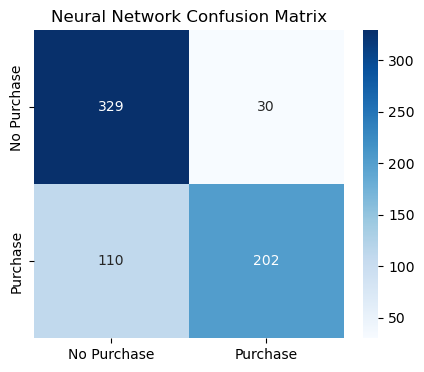

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)
plt.title('Neural Network Confusion Matrix')
plt.savefig('nn_cm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()